In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler , MinMaxScaler, RobustScaler


In [2]:
df = pd.read_csv("clean_listings.csv")

In [3]:
df.head()

,completion_status,price_egp,city,town,district,bedrooms,bathrooms,area_value,furnished,listing_level,...,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km,price_category
0,Off Plan,5145000.0,Giza,Sheikh Zayed City,Sheikh Zayed Compounds,2,2,123.0,PARTLY,premium,...,3,1.988,3,6.410,0,8.264,0,1.451,11,Low
1,Ready,10800000.0,Cairo,New Cairo City,5th Settlement,4,4,250.0,Unknown,premium,...,0,7.706,0,6.502,0,7.395,0,3.353,0,High
2,Ready,10500000.0,Cairo,New Cairo City,5th Settlement,2,2,136.0,Furnished,premium,...,0,4.024,0,2.407,1,3.597,0,1.225,1,High
3,Ready,11750000.0,Giza,Sheikh Zayed City,12th District,4,2,209.0,Unfurnished,premium,...,5,0.295,4,7.238,0,5.803,0,0.884,8,High
4,Ready,21919586.4,Giza,6 October City,6 October Compounds,3,3,285.0,Unfurnished,premium,...,6,0.597,3,3.303,0,1.322,1,0.583,11,High


In [39]:
df.describe()

,price_egp,bedrooms,bathrooms,area_value,images_count,dist_nearest_school_km,school_count_within_3km,dist_nearest_hospital_km,hospital_count_within_3km,dist_nearest_supermarket_km,supermarket_count_within_3km,dist_nearest_mall_km,mall_count_within_3km,dist_nearest_transit_station_km,transit_station_count_within_3km,dist_nearest_cafe_restaurant_km,cafe_restaurant_count_within_3km
count,2.692300e+04,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000,26923.000000
mean,7.785226e+06,2.626119,2.303978,152.318761,11.561156,4.414862,2.476730,5.677155,3.080712,3.288991,9.416670,6.525178,0.598187,5.460562,1.157486,2.762360,14.120417
std,4.458251e+06,0.711493,0.777637,49.568651,4.416978,7.241133,4.613726,8.185875,7.401824,3.685831,16.553706,12.424386,1.390764,3.261044,3.779931,3.628537,28.476928
min,1.573968e+06,1.000000,1.000000,40.000000,1.000000,0.041000,0.000000,0.010000,0.000000,0.009000,0.000000,0.066000,0.000000,0.013000,0.000000,0.002000,0.000000
25%,4.570326e+06,2.000000,2.000000,121.000000,9.000000,1.307000,0.000000,1.513000,0.000000,0.803000,0.000000,2.524000,0.000000,2.997000,0.000000,0.734000,0.000000
50%,6.600000e+06,3.000000,2.000000,150.000000,10.000000,2.572000,1.000000,3.404000,0.000000,1.834000,2.000000,4.470000,0.000000,4.968000,0.000000,1.528000,3.000000
75%,9.938500e+06,3.000000,3.000000,179.000000,13.000000,4.272000,3.000000,6.608000,3.000000,4.194000,9.000000,6.878000,1.000000,7.587000,1.000000,3.225000,12.000000
max,2.191959e+07,7.000000,8.000000,320.000000,58.000000,51.864000,32.000000,59.521000,59.000000,16.919840,90.000000,99.012000,10.000000,19.397000,40.000000,20.291000,253.000000


In [4]:
df.columns

Index(['completion_status', 'price_egp', 'city', 'town', 'district',
       'bedrooms', 'bathrooms', 'area_value', 'furnished', 'listing_level',
       'is_premium', 'is_featured', 'is_direct_from_developer', 'images_count',
       'amenities', 'dist_nearest_school_km', 'school_count_within_3km',
       'dist_nearest_hospital_km', 'hospital_count_within_3km',
       'dist_nearest_supermarket_km', 'supermarket_count_within_3km',
       'dist_nearest_mall_km', 'mall_count_within_3km',
       'dist_nearest_transit_station_km', 'transit_station_count_within_3km',
       'dist_nearest_cafe_restaurant_km', 'cafe_restaurant_count_within_3km',
       'price_category'],
      dtype='object')

In [40]:
for col in df.columns:
    unique_values = df[col].nunique()
    values = df[col].unique()
    print(f"{col}: {unique_values} unique values")
    print(f"Values: {values}\n")

completion_status: 5 unique values
Values: ['Off Plan' 'Ready' 'completed_primary' 'off_plan_primary'
 'under-construction']

price_egp: 5056 unique values
Values: [ 5145000. 10800000. 10500000. ...  5142000.  3268000.  9711750.]

city: 19 unique values
Values: ['Giza' 'Cairo' 'Red Sea' 'North Coast' 'Suez' 'Alexandria' 'Qalyubia'
 'Matrouh' 'Al Daqahlya' 'Sharqia' 'Demyat' 'Matruh' 'Damietta' 'Asyut'
 'Ismailia' 'Sohag' 'Gharbia' 'Sinai' 'Dakahlia']

town: 138 unique values
Values: ['Sheikh Zayed City' 'New Cairo City' '6 October City' 'Hurghada'
 'New Capital City' 'Mostakbal City - Future City' 'Badr City' 'El Nozha'
 'Hay El Haram' 'Hadayek El Ahram' 'New Heliopolis' 'Ring Road'
 'Al Alamein' 'Ras Al Hekma' 'Al Ain Al Sokhna' 'Nasr City' 'Mokattam'
 'Shorouk City' 'Mohandessin' 'Heliopolis - Masr El Gedida' 'Madinaty'
 'Hay El Maadi' 'Hay Sharq' 'Hay Wasat' 'Alexandria Compounds' 'Noor City'
 'El Khalifa' 'Al Agouza' 'Zamalek' 'Obour City' 'Marsa Alam'
 'Ganoub El Giza' 'Dokki' 'Ne

In [41]:


import seaborn as sns
import matplotlib.pyplot as plt

def show_histogram_with_stats(df, column_name):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True, color="skyblue", bins=50, alpha=0.5)
    plt.axvline(df[column_name].mean(), color="red", linestyle="dashed", linewidth=1, label="Mean")
    plt.axvline(df[column_name].median(), color="green", linestyle="dashed", linewidth=1, label="Median")
    plt.legend()
    plt.title('Original ' + column_name.capitalize() + ' Distribution')
    plt.xlabel(column_name.capitalize())
    plt.ylabel('Count')
    plt.show()


# Split Data into Train and Test Sets   

In [42]:
# split data into train and test sets
from sklearn.model_selection import train_test_split
X = df.drop('price_egp', axis=1)
X = df.drop('price_category', axis=1)
y = df['price_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
# split trian to train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Feature interaction

### (1) : split amenities

In [61]:

amenities

array(['', 'balcony', 'covered parking', 'lobby in building',
       'maids room', 'security', 'shared gym', 'shared pool',
       'shared spa', 'study', 'view of water', 'walk-in closet',
       'built in wardrobes', 'central a/c', "children's pool",
       'kitchen appliances', 'private garden', 'private pool',
       'view of landmark'], dtype=object)

In [63]:

X_train[['balcony', "children's pool", 'security', 'covered parking', 'lobby in building']].head()


,balcony,children's pool,security,covered parking,lobby in building
13815,0,0,0,0,0
5861,1,0,1,1,1
22230,0,0,0,0,0
3999,1,1,1,1,1
20644,0,0,0,0,0


In [ ]:
X_train['amenities_count'] = X_train['amenities'].str.split(',').apply(len)
X_train['luxury_score']= X_train[['private pool', "private garden", 'view of water', 'covered parking']].sum(axis=1)
X_train['district_frequency']= X_train['district'].map(X_train['district'].value_counts(normalize=True))
X_train['town_frequency']= X_train['town'].map(X_train['town'].value_counts(normalize=True))
X_train['bedroom_density']= X_train['bedrooms'] / (X_train['area_value'] + 1e-5) 
X_train['bathroom_density']= X_train['bathrooms'] / (X_train['area_value'] + 1e-5)
X_train['total_rooms']= X_train['bedrooms'] + X_train['bathrooms']
X_train['room_density']= X_train['total_rooms'] / (X_train['area_value'] + 1e-5)
###################################################################################
X_train['accessibility_score']= X_train['school_count_within_3km'] + X_train['hospital_count_within_3km'] + X_train['supermarket_count_within_3km']+ X_train['transit_station_count_within_3km']
X_train['lifestyle_score'] = X_train['mall_count_within_3km '] + X_train['cafe_restaurant_count_within_3km']
####################################################################################
X_train['dist_nearest_school_km ']=1/(X_train['dist_nearest_school_km'] + 1e-5)
X_train['dist_nearest_hospital_km ']=1/(X_train['dist_nearest_hospital_km'] + 1e-5)
X_train['dist_nearest_supermarket_km ']=1/(X_train['dist_nearest_supermarket_km'] + 1e-5)
X_train['dist_nearest_transit_km ']=1/(X_train['dist_nearest_transit_km'] + 1e-5)
X_train['dist_nearest_mall_km ']=1/(X_train['dist_nearest_mall_km'] + 1e-5)
X_train['dist_nearest_cafe_km ']=1/(X_train['dist_nearest_cafe_km'] + 1e-5)

# Feature Scaling 
-   standardization
-   Min-Max Scaling
-   Robust Scaling 

**Transform numerical features to a common scale.**

We choose scaling based on:

-   distribution shape (normal or skewed)
-   outliers           (as it not suitable to apply min-max on such data)
-   bounded values    
-   model sensitivity

###  (1) **price_egp**

- *mean* = 7.8M
- *std* = 4.4M
- *min* = 1.57M
- *max* = 21.9M
- *median* = 6.6M

#### *mean* > *median*

**So right-skewed so will apply Robust Scaling** 

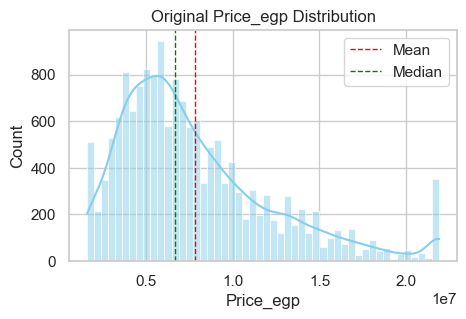

In [66]:

show_histogram_with_stats(X_train, 'price_egp')

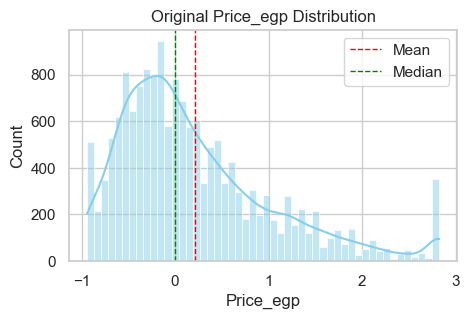

In [76]:
# apply scaling 
scaler = RobustScaler()
X_train['price_egp'] = scaler.fit_transform(X_train[['price_egp']])
X_val['price_egp'] = scaler.transform(X_val[['price_egp']])
X_test['price_egp'] = scaler.transform(X_test[['price_egp']])
show_histogram_with_stats(X_train, 'price_egp')



###  (2) **bedrooms**`

**Values**:
1–7 only.

Discrete bounded variable.

Not continuous.

**Min-Max**

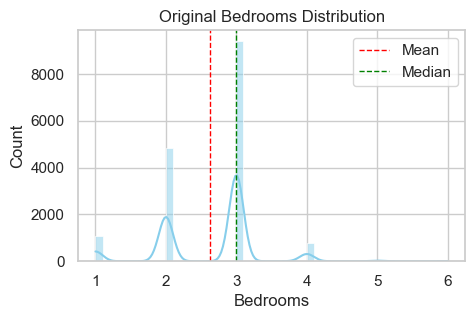

In [67]:
show_histogram_with_stats(X_train, 'bedrooms')

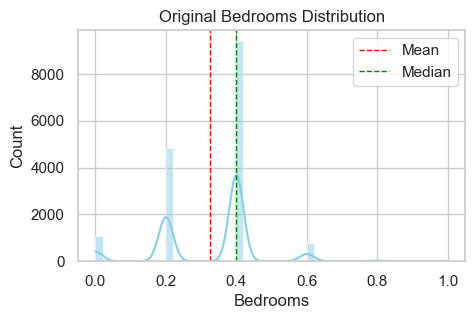

In [78]:
# apply scaling 
scaler = MinMaxScaler()
X_train['bedrooms'] = scaler.fit_transform(X_train[['bedrooms']])
X_val['bedrooms'] = scaler.transform(X_val[['bedrooms']])
X_test['bedrooms'] = scaler.transform(X_test[['bedrooms']])
show_histogram_with_stats(X_train, 'bedrooms')



###  (3) **bathrooms**

Values:
1–8.

Same as bedrooms.


**Min-Max**

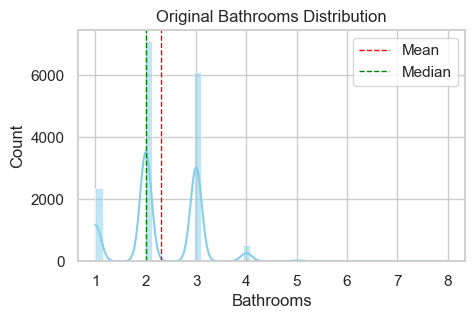

In [68]:
show_histogram_with_stats(X_train, 'bathrooms')

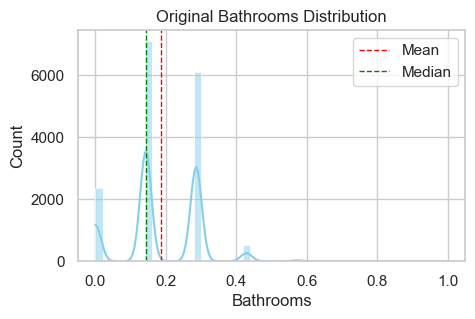

In [80]:
# apply scaling 
scaler = MinMaxScaler()
X_train['bathrooms'] = scaler.fit_transform(X_train[['bathrooms']])
X_val['bathrooms'] = scaler.transform(X_val[['bathrooms']])
X_test['bathrooms'] = scaler.transform(X_test[['bathrooms']])
show_histogram_with_stats(X_train, 'bathrooms')



###  (4) **area_value**
- *min* 40
- *max* 320
- *mean* 152
- *median* 150

**mean = median** <br>
**So normal distribution so will apply Standardization**

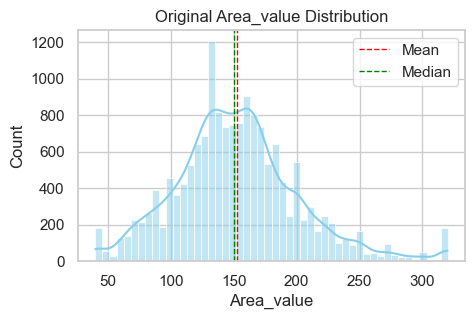

In [ ]:
show_histogram_with_stats(X_train, 'area_value')


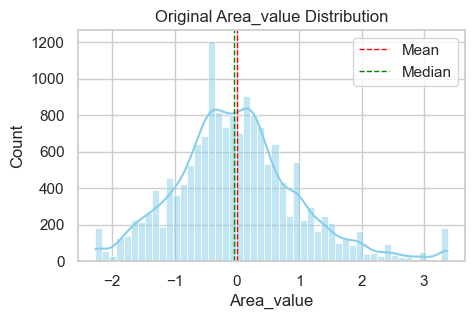

In [ ]:

# apply scaling 
scaler = StandardScaler()
X_train['area_value'] = scaler.fit_transform(X_train[['area_value']])
X_val['area_value'] = scaler.transform(X_val[['area_value']])
X_test['area_value'] = scaler.transform(X_test[['area_value']])
#after
show_histogram_with_stats(X_train, 'area_value')



###  (5) **images_count**

Values:
1–58

- *mean* 11.5
- *median* 10
- *max* 58

Right-skewed. <br>
**So will apply Robust Scaling**

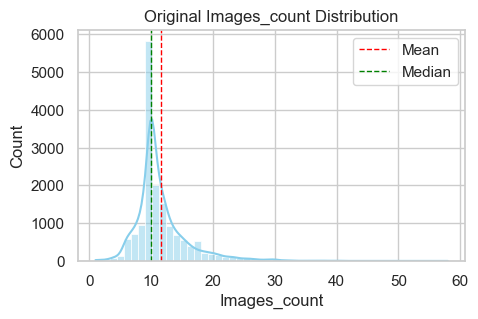

In [70]:
show_histogram_with_stats(X_train, 'images_count')

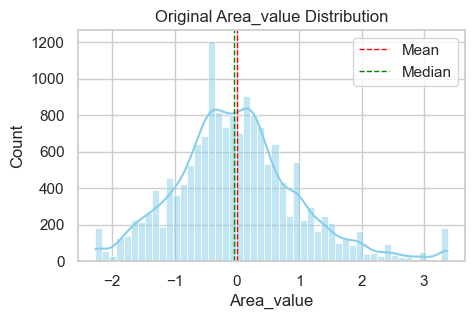

In [ ]:

# apply scaling 
scaler = RobustScaler()
X_train['images_count'] = scaler.fit_transform(X_train[['images_count']])
X_val['images_count'] = scaler.transform(X_val[['images_count']])
X_test['images_count'] = scaler.transform(X_test[['images_count']])
#after
show_histogram_with_stats(X_train, 'images_count')

###  (6) **distance features**
- *dist_nearest_school_km*
- *dist_nearest_hospital_km*
- *dist_nearest_supermarket_km*
- *dist_nearest_mall_km*
- *dist_nearest_transit_station_km*
- *dist_nearest_cafe_restaurant_km*

right skewed. <br>
**So will apply Robust Scaling**

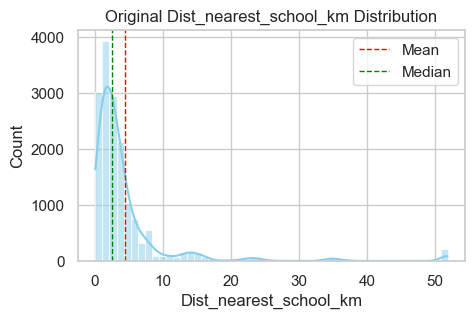

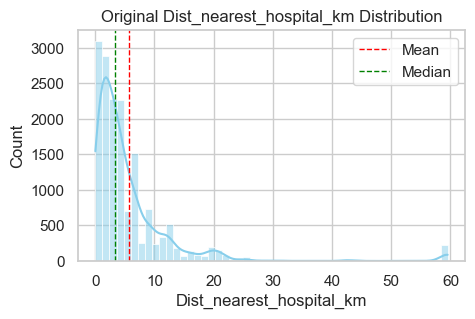

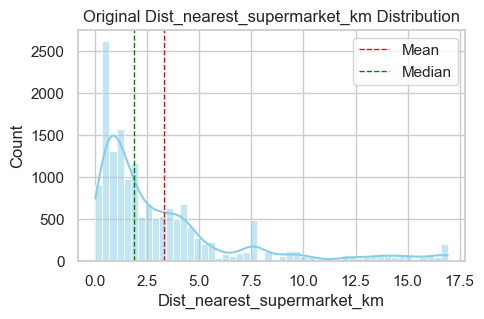

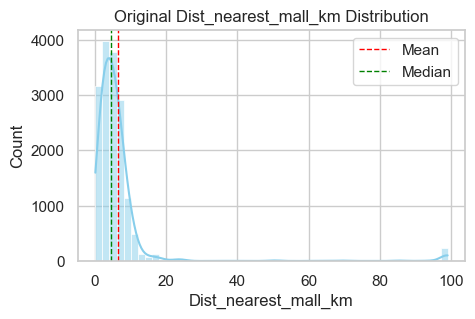

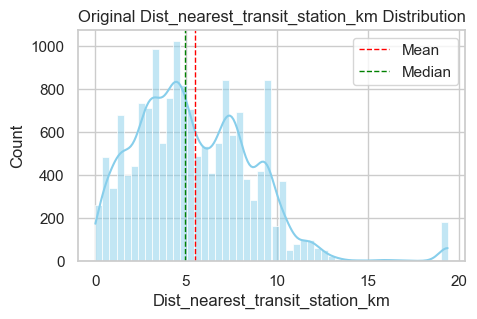

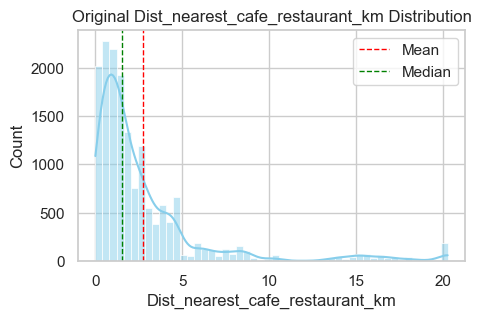

In [71]:
for col in X_train.columns:
    if col.startswith('dist_nearest'):
        show_histogram_with_stats(X_train, col)

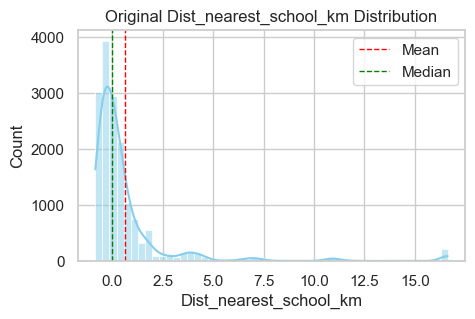

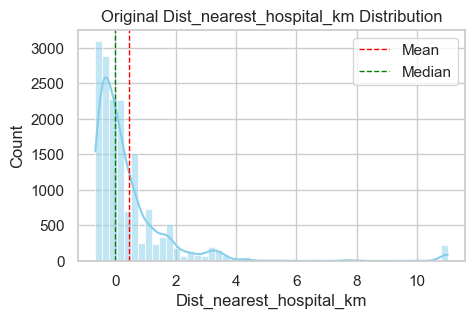

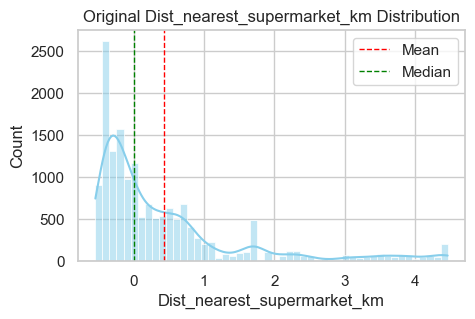

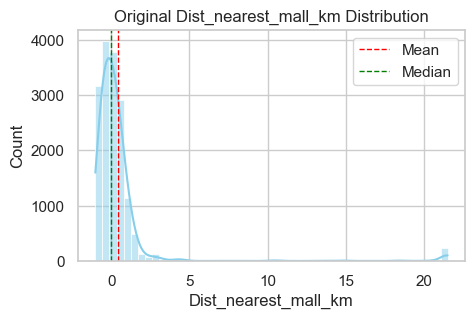

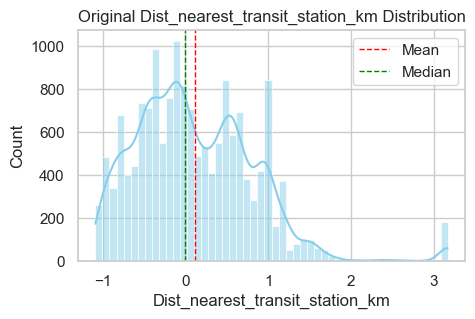

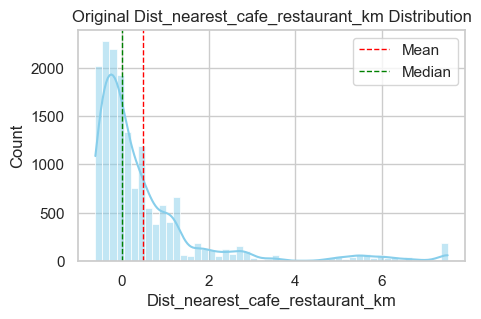

In [83]:

for col in X_train.columns:
    if col.startswith('dist_nearest'):
        scaler = RobustScaler()
        X_train[col] = scaler.fit_transform(X_train[[col]])
        X_val[col] = scaler.transform(X_val[[col]])
        X_test[col] = scaler.transform(X_test[[col]])
        show_histogram_with_stats(X_train, col)

###  (7) **Count features**
- *school_count_within_3km*
- *hospital_count_within_3km*
- *supermarket_count_within_3km*
- *mall_count_within_3km*
- *transit_station_count_within_3km*
- *cafe_restaurant_count_within_3km*

mall_count_within_3km has 0–10 values, so min-max scaling or no scaling as range is small. <br>

rest of the count featur as skewed, so will apply Robust Scaling.

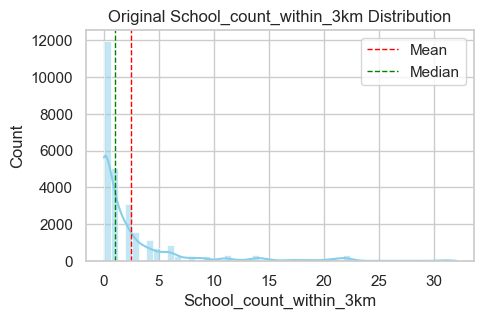

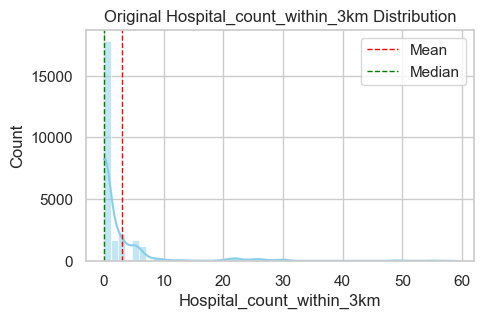

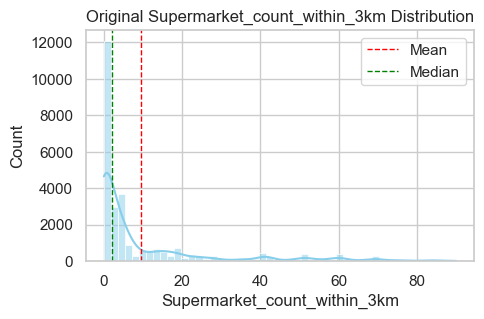

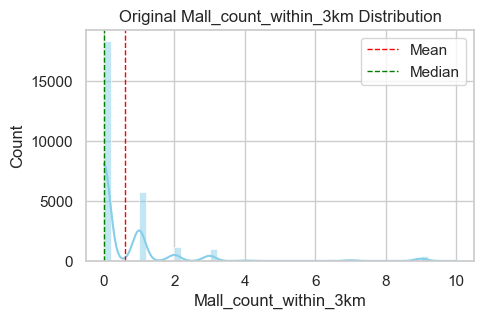

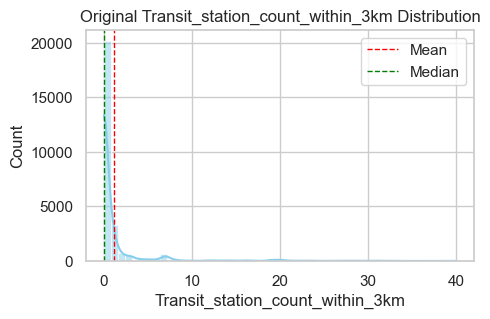

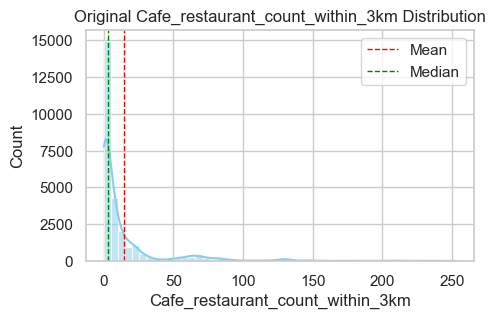

In [72]:
for col in df.columns:
    if col.endswith('count_within_3km'):
        show_histogram_with_stats(df, col)

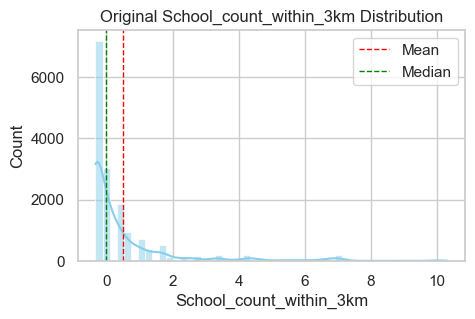

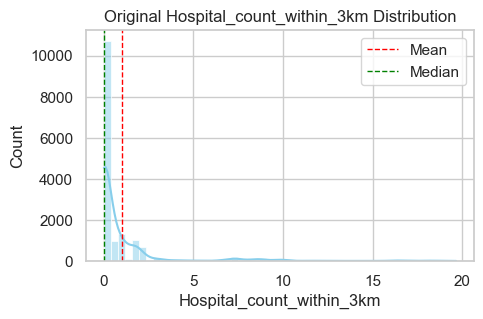

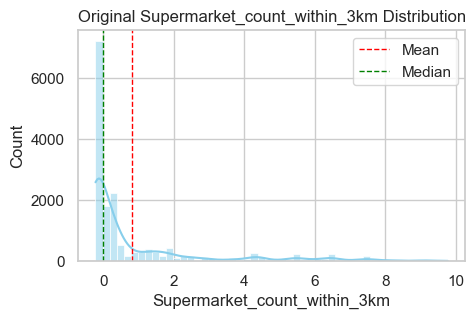

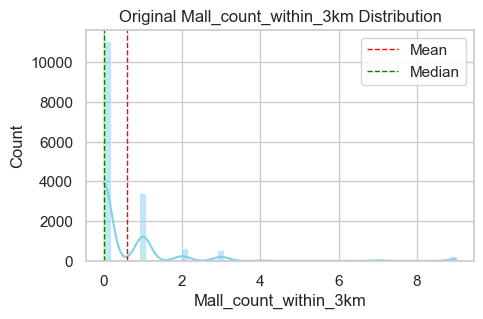

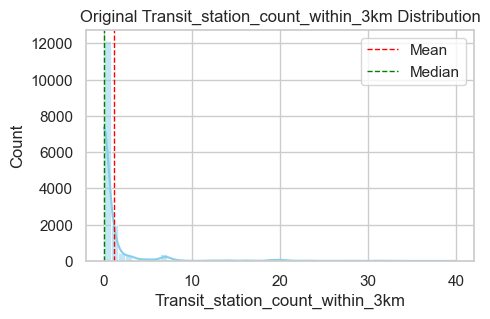

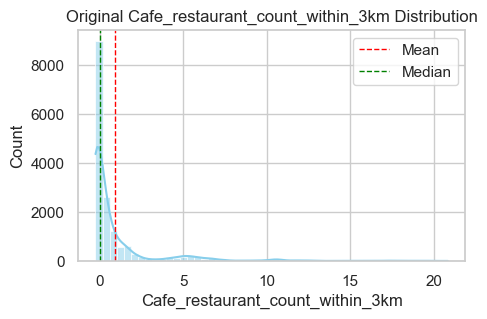

In [85]:
for col in df.columns:
    if col.endswith('count_within_3km'):
        scaler = RobustScaler()
        X_train[col] = scaler.fit_transform(X_train[[col]])
        X_val[col] = scaler.transform(X_val[[col]])
        X_test[col] = scaler.transform(X_test[[col]])
        show_histogram_with_stats(X_train, col)

# Feature Encoding 
-   One-Hot Encoding
-   Label Encoding
-   Target Encoding
-   Binary Encoding
-   Frequency Encoding
-   Rare Encoding

### (1) **convert bool to  int**
-   *is_premium*
-   *is_featured*
-   *is_direct_from_developer*

In [ ]:
bool_cols = [
    "is_premium",
    "is_featured",
    "is_direct_from_developer"
]

for df_ in [X_train, X_val, X_test]:
    df_[bool_cols] = df_[bool_cols].astype(int)

### (2) **Ordinal encode**  listing_level 
-   *standard* = 0
-  *featured* = 1
-  *premium* = 2
-  *hot* = 3
-  *superhot* = 4

as there is a clear order will apply Label Encoding

In [89]:
listing_map = {
    "standard": 0,
    "featured": 1,
    "premium": 2,
    "hot": 3,
    "superhot": 4
}

for df_ in [X_train, X_val, X_test]:
    df_["listing_level"] = df_["listing_level"].map(listing_map)

### (3) **completion_status**
-   *Ready*                 
-   *under-construction*    
-   *off_plan_primary*      
-   *completed_primary*     
-   *Off Plan*

### (4) **furnished**
-   *Unfurnished*    
-   *Unknown*         
-   *Furnished*        
-   *PARTLY*

we will apply one-hot encoding for both completion_status and furnished as they are nominal categorical variables with no clear order.

In [ ]:
one_hot_cols = ["completion_status", "furnished"]

combined = pd.concat([X_train, X_val, X_test], axis=0)

combined = pd.get_dummies(
    combined,
    columns= one_hot_cols,
    drop_first=True
)

X_train = combined.iloc[:len(X_train)]
X_val = combined.iloc[len(X_train):len(X_train) + len(X_val)]
X_test = combined.iloc[len(X_train) + len(X_val):]



### (5) Frequency encode 
-   *city*
-   *town*
-   *district*

In [ ]:
freq_cols = ["city", "town", "district"]

for col in freq_cols:
    freq_map = X_train[col].value_counts(normalize=True)

    X_train[col] = X_train[col].map(freq_map)
    X_val[col] = X_val[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map)

    # for unseen categories in val and test sets, fill with 0
    X_val[col] = X_val[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

### (6) amenities convert to binary features


In [ ]:
# split in amenities and create binary features for each amenity
X_train['amenities'] = X_train['amenities'].fillna('')
amenities = X_train['amenities'].str.split(',').explode().str.strip().unique()
for amenity in amenities:
    X_train[amenity] = X_train['amenities'].str.contains(amenity).astype(int)
    X_val[amenity] = X_val['amenities'].str.contains(amenity).astype(int)
    X_test[amenity] = X_test['amenities'].str.contains(amenity).astype(int)

# Discretization and Binning
-   Equal Width Binning
-   Equal Frequency Binning

**for some feature that is may be hard to model as continuous variable, we can try to discretize it into bins and convert it to categorical variable.**

## (1) Area
- min = 40
- max = 320
- Q1 = 121
- median = 150
- Q3 = 179

In [ ]:
area_bins = [0, 100, 150, 220, float("inf")]

for df_ in [X_train, X_val, X_test]:
    df_["area_bin"] = pd.cut(
        df_["area_value"],
        bins=area_bins,
        labels=[0, 1, 2, 3],
        include_lowest=True
    ).astype(int)

## (2) bedrooms
- min = 1
- max = 7
- median = 3
- most values = 2–3 bedrooms

In [ ]:
bedroom_bins = [0, 2, 4, float("inf")]

for df_ in [X_train, X_val, X_test]:
    df_["bedrooms_bin"] = pd.cut(
        df_["bedrooms"],
        bins=bedroom_bins,
        labels=[0, 1, 2],
        include_lowest=True
    ).astype(int)

## (3) bathrooms
- min = 1
- max = 8
- median = 2

In [ ]:
bathroom_bins = [0, 2, 4, float("inf")]

for df_ in [X_train, X_val, X_test]:
    df_["bathrooms_bin"] = pd.cut(
        df_["bathrooms"],
        bins=bathroom_bins,
        labels=[0, 1, 2],
        include_lowest=True
    ).astype(int)

### (4) distance features

In [ ]:
distance_cols = [
    "dist_nearest_school_km",
    "dist_nearest_hospital_km",
    "dist_nearest_supermarket_km",
    "dist_nearest_mall_km",
    "dist_nearest_transit_station_km",
    "dist_nearest_cafe_restaurant_km"
]
distance_bins = [0, 1, 3, 7, float("inf")]

for col in distance_cols:
    for df_ in [X_train, X_val, X_test]:
        df_[f"{col}_bin"] = pd.cut(
            df_[col],
            bins=distance_bins,
            labels=[0, 1, 2, 3],
            include_lowest=True
        ).astype(int)

In [ ]:
count_cols = [
    "school_count_within_3km",
    "hospital_count_within_3km",
    "supermarket_count_within_3km",
    "mall_count_within_3km",
    "transit_station_count_within_3km",
    "cafe_restaurant_count_within_3km"
]

for col in count_cols:
    X_train[col + "_bin"] = pd.cut(
        X_train[col],
        bins=[-1, 0, 3, 10, float("inf")],
        labels=[0, 1, 2, 3]
    ).astype(int)

    X_val[col + "_bin"] = pd.cut(
        X_val[col],
        bins=[-1, 0, 3, 10, float("inf")],
        labels=[0, 1, 2, 3]
    ).astype(int)

    X_test[col + "_bin"] = pd.cut(
        X_test[col],
        bins=[-1, 0, 3, 10, float("inf")],
        labels=[0, 1, 2, 3]
    ).astype(int)

### (5) amenities count
- min = 0
- max = 253
- median = 3
- mean = 14

In [ ]:
X_train["amenities_count_bin"], bins = pd.qcut(
    X_train["amenities_count"],
    q=4,
    labels=False,
    retbins=True,
    duplicates="drop"
)

X_val["amenities_count_bin"] = pd.cut(
    X_val["amenities_count"],
    bins=bins,
    labels=False,
    include_lowest=True
)

X_test["amenities_count_bin"] = pd.cut(
    X_test["amenities_count"],
    bins=bins,
    labels=False,
    include_lowest=True
)

In [ ]:
luxury_bins = [-1, 0, 2, float("inf")]

for df_ in [X_train, X_val, X_test]:
    df_["luxury_bin"] = pd.cut(
        df_["luxury_score"],
        bins=luxury_bins,
        labels=[0, 1, 2],
        include_lowest=True
    ).astype(int)

# Feature Interactions
-   Arithmetic Complications
-   Statistical Aggregations
-   Boolean and Logical Combinations


# Feature Selection
-   Filter Methods
-   Wrapper Methods
-   pemutation importance

# Documentation
